# MIMO Convolution — Single-Shot Multiplexed Packing (Orion 4.2–4.3) + Çok-Katmanlı Zincirleme



## Kurulum

OpenFHE için Python 3.10 ortamı

In [1]:
!pip install -q uv
!uv python install 3.10
!uv venv /content/fhe310 --python 3.10
!uv pip install --python /content/fhe310/bin/python "openfhe==1.5.1.0.22.4" numpy scipy
!/content/fhe310/bin/python -c "import openfhe, sys; print('OpenFHE hazir, Python', sys.version.split()[0])"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 51.8 MB/s eta 0:00:00
Installed Python 3.10.20 in 1.20s
 + cpython-3.10.20-linux-x86_64-gnu (python3.10)
Using CPython 3.10.20
Creating virtual environment at: fhe310
Activate with: source fhe310/bin/activate
Using Python 3.10.20 environment at: fhe310
Resolved 3 packages in 248ms
Prepared 3 packages in 1.10s
Installed 3 packages in 32ms
 + numpy==2.2.6
 + openfhe==1.5.1.0.22.4
 + scipy==1.15.3
OpenFHE hazir, Python 3.10.20


## FHE kodu

Tüm mantık tek script'te: SISO/MIMO Toeplitz, multiplexed Toeplitz, (de)multiplex, diagonal çıkarma, BSGS planlayıcı, depth-1 FHE matvec (plain + BSGS), ciphertext-girdili matvec (zincirleme) ve deney modları.

In [2]:
%%writefile /content/mimo_mux_fhe.py
import argparse, json, os, math, time
import numpy as np

OUT = "/content"
os.makedirs(OUT, exist_ok=True)

def _import_fhe():
    from openfhe import CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE
    return CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE

def build_toeplitz_siso(H_in, W_in, kernel, stride=1, padding=0, dilation=1):
    sH = sW = stride; pH = pW = padding; dH = dW = dilation
    kH, kW = kernel.shape
    H_pad, W_pad = H_in + 2*pH, W_in + 2*pW
    eff_kH = (kH-1)*dH + 1; eff_kW = (kW-1)*dW + 1
    H_out = (H_pad - eff_kH)//sH + 1; W_out = (W_pad - eff_kW)//sW + 1
    idx = -np.ones((H_pad, W_pad), int)
    idx[pH:pH+H_in, pW:pW+W_in] = np.arange(H_in*W_in).reshape(H_in, W_in)
    T = np.zeros((H_out*W_out, H_in*W_in))
    for oh in range(H_out):
        for ow in range(W_out):
            r = oh*W_out + ow
            for kh in range(kH):
                for kw in range(kW):
                    s = idx[oh*sH + kh*dH, ow*sW + kw*dW]
                    if s >= 0: T[r, s] += kernel[kh, kw]
    return T, (H_out, W_out)

def build_mimo_block_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation=1):
    """Figure 3 / 4a: cikti kanallari satir bloklarina, girdi kanallari sutun bloklarina.
    y[co] = sum_ci T[co,ci] @ x[ci]. Tek buyuk matris -> tek matvec -> depth 1."""
    _, (Ho, Wo) = build_toeplitz_siso(Hi, Wi, weight[0, 0], stride, padding, dilation)
    T = np.zeros((Co*Ho*Wo, Ci*Hi*Wi))
    for co in range(Co):
        for ci in range(Ci):
            Tb, _ = build_toeplitz_siso(Hi, Wi, weight[co, ci], stride, padding, dilation)
            T[co*Ho*Wo:(co+1)*Ho*Wo, ci*Hi*Wi:(ci+1)*Hi*Wi] = Tb
    return T, (Ho, Wo)

def build_mux_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation=1, iG=1):
    kH, kW = weight.shape[2], weight.shape[3]; D = dilation; P = padding
    oG = iG*stride
    Ho = (Hi + 2*P - ((kH-1)*D+1))//stride + 1
    Wo = (Wi + 2*P - ((kW-1)*D+1))//stride + 1
    on_Ci = math.ceil(Ci/(iG**2)); on_Hi = Hi*iG; on_Wi = Wi*iG
    on_Co = math.ceil(Co/(oG**2)); on_Ho = Ho*oG; on_Wo = Wo*oG
    Hi_pad = on_Hi + 2*P*iG; Wi_pad = on_Wi + 2*P*iG
    n_rows = on_Co*on_Ho*on_Wo; n_cols = on_Ci*Hi_pad*Wi_pad
    vii = np.arange(n_cols).reshape(on_Ci, Hi_pad, Wi_pad)
    kernel = np.zeros((on_Co*oG**2, on_Ci*iG**2, kH, kW))
    kernel[:Co, :Ci] = weight
    mpx = vii[:, :iG, :iG].reshape(-1, 1)
    ri = np.arange(0, kH*D*iG, D*iG).reshape(-1, 1)
    ci = np.arange(0, kW*D*iG, D*iG)
    koff = vii[0][ri, ci].flatten()
    ikp = (mpx + koff).flatten()
    oi = np.arange(on_Ho*on_Wo).reshape(on_Ho, on_Wo)
    start = oi[:oG, :oG].flatten()
    corner = oi[0:Ho*oG:oG, 0:Wo*oG:oG].reshape(-1, 1)
    row_map = corner + start
    corner_img = vii[0, 0:Ho*oG:oG, 0:Wo*oG:oG].flatten()
    out_ch = (np.arange(on_Co)*(on_Ho*on_Wo)).reshape(on_Co, 1)
    kflat = kernel.reshape(kernel.shape[0], -1)
    T = np.zeros((n_rows, n_cols))
    for i, sidx in enumerate(corner_img):
        rows = (row_map[i] + out_ch).reshape(-1, 1)
        cols = ikp + sidx
        T[rows, cols] = kflat
    ri2 = np.arange(P*iG, P*iG + on_Hi).reshape(-1, 1)
    ci2 = np.arange(P*iG, P*iG + on_Wi)
    img_idx = vii[:, ri2, ci2].flatten()
    T = T[:, img_idx]
    return T, (on_Co, on_Ho, on_Wo), (Ho, Wo, oG)

def demultiplex(vec, on_Co, on_Ho, on_Wo, Co, Ho, Wo, oG):
    """Ters pixel-shuffle: multiplexed cikti -> (Co, Ho, Wo)."""
    t = np.asarray(vec).reshape(on_Co, on_Ho, on_Wo)
    out = np.zeros((on_Co*oG**2, Ho, Wo))
    for c in range(on_Co):
        for a in range(oG):
            for b in range(oG):
                out[c*oG**2 + a*oG + b] = t[c, a::oG, b::oG]
    return out[:Co]

def conv_ref(x, weight, stride, padding, dilation=1):
    Ci, Hi, Wi = x.shape; Co = weight.shape[0]; kH, kW = weight.shape[2:]
    xp = np.pad(x, ((0, 0), (padding, padding), (padding, padding)))
    eff_kH = (kH-1)*dilation + 1; eff_kW = (kW-1)*dilation + 1
    Ho = (Hi + 2*padding - eff_kH)//stride + 1
    Wo = (Wi + 2*padding - eff_kW)//stride + 1
    o = np.zeros((Co, Ho, Wo))
    for co in range(Co):
        for oh in range(Ho):
            for ow in range(Wo):
                acc = 0.0
                for ci in range(Ci):
                    for kh in range(kH):
                        for kw in range(kW):
                            acc += xp[ci, oh*stride + kh*dilation, ow*stride + kw*dilation]*weight[co, ci, kh, kw]
                o[co, oh, ow] = acc
    return o

def next_pow2(n):
    p = 1
    while p < n: p *= 2
    return p

def nonzero_diagonals(T, S):
    R, C = T.shape
    M = np.zeros((S, S)); M[:R, :C] = T
    base = np.arange(S); diags = {}
    for k in range(S):
        d = M[base, (base + k) % S]
        if np.any(d != 0): diags[k] = d
    return diags

def plan_bsgs(diag_keys, S):
    """En az rotasyon veren baby-step boyutu n1'i sec. Depth = 1 korunur."""
    keys = sorted(diag_keys)
    best = None
    for n1 in range(1, S + 1):
        baby = set(k % n1 for k in keys)
        giant = set(k // n1 for k in keys)
        rot = len(baby - {0}) + len(giant - {0})
        if best is None or rot < best[0]:
            best = (rot, n1, baby, giant)
    return best

def build_cc(S, depth=1, scale=50):
    CCParamsCKKSRNS, GenCryptoContext, PKE, KEYSWITCH, LEVELEDSHE = _import_fhe()
    p = CCParamsCKKSRNS()
    p.SetMultiplicativeDepth(depth)
    p.SetScalingModSize(scale)
    p.SetBatchSize(S)
    cc = GenCryptoContext(p)
    cc.Enable(PKE); cc.Enable(KEYSWITCH); cc.Enable(LEVELEDSHE)
    return cc

def he_matvec_plain(cc, keys, x_vec, diag_pts, S, repeats=3):
    times = []; ct_final = None
    for _ in range(max(1, repeats)):
        xp = np.zeros(S); xp[:len(x_vec)] = x_vec
        ct_x = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(list(xp)))
        t0 = time.perf_counter(); ct_acc = None
        for k, pt in diag_pts.items():
            ct_rot = ct_x if k == 0 else cc.EvalRotate(ct_x, k)
            part = cc.EvalMult(ct_rot, pt)
            ct_acc = part if ct_acc is None else cc.EvalAdd(ct_acc, part)
        times.append(time.perf_counter() - t0); ct_final = ct_acc
    return ct_final, float(np.mean(times)), float(np.std(times))

def he_matvec_bsgs(cc, keys, x_vec, diags, S, n1, repeats=3):
    grouped = {}
    for k, d in diags.items():
        j, i = k // n1, k % n1
        pt = cc.MakeCKKSPackedPlaintext(list(np.roll(d, n1*j)))
        grouped.setdefault(j, []).append((i, pt))
    baby_idx = sorted({i for terms in grouped.values() for (i, _) in terms} - {0})
    times = []; ct_final = None
    for _ in range(max(1, repeats)):
        xp = np.zeros(S); xp[:len(x_vec)] = x_vec
        ct_x = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(list(xp)))
        t0 = time.perf_counter()
        babies = {0: ct_x}
        for i in baby_idx:
            babies[i] = cc.EvalRotate(ct_x, i)
        acc = None
        for j, terms in grouped.items():
            inner = None
            for (i, pt) in terms:
                part = cc.EvalMult(babies[i], pt)
                inner = part if inner is None else cc.EvalAdd(inner, part)
            rot = inner if j == 0 else cc.EvalRotate(inner, n1*j)
            acc = rot if acc is None else cc.EvalAdd(acc, rot)
        times.append(time.perf_counter() - t0); ct_final = acc
    return ct_final, float(np.mean(times)), float(np.std(times))

def he_diag_matvec_ct(cc, ct_in, diag_pts):
    """Sifreli girdi -> sifreli cikti. diag_pts: {k: plaintext}. Katman depth'i = 1."""
    ct_acc = None
    for k, pt in diag_pts.items():
        ct_rot = ct_in if k == 0 else cc.EvalRotate(ct_in, k)
        part = cc.EvalMult(ct_rot, pt)
        ct_acc = part if ct_acc is None else cc.EvalAdd(ct_acc, part)
    return ct_acc

def run_experiment(name, x, weight, stride, padding, dilation=1, method="both",
                   atol=5e-2, repeats=3, save_prefix=None, do_fhe=True):
    Ci, Hi, Wi = x.shape; Co = weight.shape[0]
    expected = conv_ref(x, weight, stride, padding, dilation)
    Ho, Wo = expected.shape[1], expected.shape[2]
    T_base, _ = build_mimo_block_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation)
    S_base = next_pow2(max(T_base.shape))
    base_diags = nonzero_diagonals(T_base, S_base)
    _t_build = time.perf_counter()
    T_mux, (oC, oH, oW), (Ho2, Wo2, oG) = build_mux_toeplitz(Ci, Hi, Wi, Co, weight, stride, padding, dilation)
    build_time = time.perf_counter() - _t_build
    S = next_pow2(max(T_mux.shape))
    mux_diags = nonzero_diagonals(T_mux, S)
    mux_keys = sorted(mux_diags.keys())
    bsgs_rot, n1, _, _ = plan_bsgs(mux_keys, S)
    plain_rot = len(mux_keys) - (1 if 0 in mux_diags else 0)

    r = dict(name=name, input_shape=[Ci, Hi, Wi], output_shape=[Co, Ho, Wo],
             mux_output_shape=[oC, oH, oW], output_gap=oG, slots=S,
             baseline_toeplitz_shape=list(T_base.shape), baseline_diagonals=len(base_diags),
             baseline_rotations=len(base_diags) - (1 if 0 in base_diags else 0),
             mux_toeplitz_shape=list(T_mux.shape), mux_diagonals=len(mux_diags),
             plain_rotations=plain_rot, bsgs_rotations=bsgs_rot, bsgs_n1=n1,
             mult_depth=1, repeats=repeats, build_time_s=build_time)

    if do_fhe:
        keys_obj = None
        cc = build_cc(S)
        keys_obj = cc.KeyGen()
        cc.EvalMultKeyGen(keys_obj.secretKey)
        results = {}
        if method in ("plain", "both"):
            rot_idx = [k for k in mux_keys if k != 0]
            if rot_idx: cc.EvalRotateKeyGen(keys_obj.secretKey, rot_idx)
            diag_pts = {k: cc.MakeCKKSPackedPlaintext(list(d)) for k, d in mux_diags.items()}
            ct, tm, ts = he_matvec_plain(cc, keys_obj, x.flatten(), diag_pts, S, repeats)
            pt = cc.Decrypt(ct, keys_obj.secretKey); pt.SetLength(oC*oH*oW)
            dec = np.array(pt.GetRealPackedValue())
            dm = demultiplex(dec, oC, oH, oW, Co, Ho, Wo, oG)
            results["plain"] = (dm, tm, ts)
        if method in ("bsgs", "both"):
            baby = sorted({k % n1 for k in mux_keys} - {0})
            giant = sorted({n1*(k // n1) for k in mux_keys} - {0})
            rk = sorted(set(baby) | set(giant))
            if rk: cc.EvalRotateKeyGen(keys_obj.secretKey, rk)
            ct, tm, ts = he_matvec_bsgs(cc, keys_obj, x.flatten(), mux_diags, S, n1, repeats)
            pt = cc.Decrypt(ct, keys_obj.secretKey); pt.SetLength(oC*oH*oW)
            dec = np.array(pt.GetRealPackedValue())
            dm = demultiplex(dec, oC, oH, oW, Co, Ho, Wo, oG)
            results["bsgs"] = (dm, tm, ts)
        for key, (dm, tm, ts) in results.items():
            r[f"{key}_match"] = bool(np.allclose(dm, expected, atol=atol))
            r[f"{key}_mae"] = float(np.abs(dm - expected).mean())
            r[f"{key}_time_mean_s"] = tm; r[f"{key}_time_std_s"] = ts
        ref_key = "plain" if "plain" in results else "bsgs"
        decrypted = results[ref_key][0]
        if save_prefix:
            np.save(f"{OUT}/{save_prefix}_input.npy", x)
            np.save(f"{OUT}/{save_prefix}_weight.npy", weight)
            np.save(f"{OUT}/{save_prefix}_expected.npy", expected)
            np.save(f"{OUT}/{save_prefix}_decrypted.npy", decrypted)
    return r

def print_result(r):
    print("=" * 70)
    print(r["name"]); print("=" * 70)
    print(f"input(C,H,W)={tuple(r['input_shape'])}  output(C,H,W)={tuple(r['output_shape'])}  "
          f"multiplexed={tuple(r['mux_output_shape'])} gap={r['output_gap']}  slots={r['slots']}")
    print(f"multiplicative depth = {r['mult_depth']}")
    print(f"[baseline MIMO Toeplitz {tuple(r['baseline_toeplitz_shape'])}] "
          f"non-zero diag={r['baseline_diagonals']}  rotations={r['baseline_rotations']}")
    print(f"[single-shot multiplexed {tuple(r['mux_toeplitz_shape'])}] "
          f"non-zero diag={r['mux_diagonals']}  plain rot={r['plain_rotations']}  "
          f"BSGS rot={r['bsgs_rotations']} (n1={r['bsgs_n1']})")
    if "plain_match" in r:
        print(f"plain: match={r['plain_match']} MAE={r['plain_mae']:.3e} "
              f"time={r['plain_time_mean_s']:.4f}+/-{r['plain_time_std_s']:.4f}s")
    if "bsgs_match" in r:
        print(f"bsgs : match={r['bsgs_match']} MAE={r['bsgs_mae']:.3e} "
              f"time={r['bsgs_time_mean_s']:.4f}+/-{r['bsgs_time_std_s']:.4f}s")
    print("=" * 70 + "\n")

def _load_mnist():
    if os.path.exists(f"{OUT}/mnist_sample.npy"):
        img = np.load(f"{OUT}/mnist_sample.npy").astype(float); src = "gercek MNIST"
    else:
        yy, xx = np.mgrid[0:28, 0:28]
        img = (128 + 100*np.sin(xx/3.0)*np.cos(yy/4.0)).clip(0, 255); src = "sentetik 28x28"
    return img/255.0, src

def run_sanity():
    rng = np.random.default_rng(0)
    configs = [(1,4,4,4,2,2,0),(2,8,8,4,3,2,1),(3,8,8,8,3,2,1),(2,8,8,4,3,1,1),
               (1,8,8,6,3,2,1),(2,9,9,9,3,3,1),(4,16,16,16,3,2,1)]
    print(f"{'in(C,H,W)':>12}{'k':>3}{'s':>3}{'p':>3}{'Co':>4}   {'out':>12}  {'match':>6}  "
          f"{'base_diag':>9}{'mux_diag':>9}{'base_rot':>9}{'plain':>7}{'bsgs':>6}")
    ok_all = True
    for (Ci,Hi,Wi,Co,k,s,p) in configs:
        W = rng.uniform(-1,1,(Co,Ci,k,k)); x = rng.uniform(-2,2,(Ci,Hi,Wi))
        ref = conv_ref(x,W,s,p)
        T,(oC,oH,oW),(Ho,Wo,oG) = build_mux_toeplitz(Ci,Hi,Wi,Co,W,s,p)
        dm = demultiplex(T@x.flatten(),oC,oH,oW,Co,Ho,Wo,oG)
        ok = np.allclose(dm,ref,atol=1e-6); ok_all &= ok
        Tb,_ = build_mimo_block_toeplitz(Ci,Hi,Wi,Co,W,s,p)
        Sb = next_pow2(max(Tb.shape)); Sm = next_pow2(max(T.shape))
        bd = len(nonzero_diagonals(Tb,Sb)); mdg = nonzero_diagonals(T,Sm); md = len(mdg)
        br,n1,_,_ = plan_bsgs(sorted(mdg.keys()),Sm)
        print(f"({Ci},{Hi},{Wi}){'':>2}{k:>3}{s:>3}{p:>3}{Co:>4}   {str((Co,Ho,Wo)):>12}  {str(ok):>6}  "
              f"{bd:>9}{md:>9}{bd-1:>9}{md-1:>7}{br:>6}")
    print(f"\n[{'OK' if ok_all else 'FAIL'}] multiplexed matvec plaintext conv ile eslesti; "
          f"reordering diagonal/rotasyon sayisini dusurdu.\n")

def run_fig4():
    rng = np.random.default_rng(4)
    x = rng.uniform(-2,2,(1,4,4)); W = rng.uniform(-1,1,(4,1,2,2))
    print_result(run_experiment("Orion Figure 4 (4x4, k=2, s=2, Ci=1, Co=4)", x, W, 2, 0,
                                method="both", atol=1e-2, repeats=15, save_prefix="fig4"))

def run_small():
    rng = np.random.default_rng(42)
    x = rng.uniform(-2,2,(2,8,8)); W = rng.uniform(-1,1,(4,2,3,3))
    print_result(run_experiment("Kucuk MIMO (Ci=2,8x8, k=3, s=2, p=1, Co=4)", x, W, 2, 1,
                                method="both", atol=2e-2, repeats=5, save_prefix="small"))

def run_mnist():
    img, src = _load_mnist(); print(f"[girdi: {src}]")
    x = img[None, :, :]
    rng = np.random.default_rng(1)
    W = rng.uniform(-1,1,(4,1,3,3))
    print_result(run_experiment("MNIST MIMO strided (Ci=1,28x28, k=3, s=2, p=1, Co=4)", x, W, 2, 1,
                                method="both", atol=5e-2, repeats=3, save_prefix="mnist"))

def run_sweep():
    rng = np.random.default_rng(7)
    cases = [
        ("Ci1 Co4  s2", 1,8,8,4,3,2,1),
        ("Ci2 Co8  s2", 2,8,8,8,3,2,1),
        ("Ci4 Co16 s2", 4,8,8,16,3,2,1),
        ("Ci4 Co32 s2", 4,8,8,32,3,2,1),
        ("Ci8 Co32 s2", 8,8,8,32,3,2,1),
        ("Ci4 Co64 s2", 4,8,8,64,3,2,1),
        ("Ci1 Co9  s3", 1,9,9,9,3,3,1),
    ]
    print(f"{'config':14s} {'out':>12} {'slots':>6} {'base_rot':>9} {'plain_rot':>10} {'bsgs_rot':>9} "
          f"{'depth':>6} {'build_s':>8} {'match':>6} {'MAE':>9}")
    print("-"*112)
    for (name,Ci,Hi,Wi,Co,k,s,p) in cases:
        x = rng.uniform(-2,2,(Ci,Hi,Wi)); W = rng.uniform(-1,1,(Co,Ci,k,k))
        r = run_experiment(name, x, W, s, p, method="both", atol=3e-2, repeats=3)
        m = r.get("plain_match", r.get("bsgs_match"))
        mae = r.get("plain_mae", r.get("bsgs_mae", 0.0))
        print(f"{name:14s} {str(tuple(r['output_shape'])):>12} {r['slots']:>6} "
              f"{r['baseline_rotations']:>9} {r['plain_rotations']:>10} {r['bsgs_rotations']:>9} "
              f"{r['mult_depth']:>6} {r['build_time_s']:>8.3f} {str(m):>6} {mae:>9.2e}")
    print("\nNot: 'build_s' = yogun (dense) mux Toeplitz'in NumPy'da kurulma suresi. Kanal/goruntu")
    print("buyudukce hizla artar; gercek Orion diyagonalleri analitik/seyrek uretir (bkz. Tartisma).")
    print()


def run_counts():
    rng = np.random.default_rng(11)
    cases = [("C1/C4 s2",1,8,8,4,3,2,1),("C2/C8 s2",2,8,8,8,3,2,1),
             ("C4/C16 s2",4,8,8,16,3,2,1),("C4/C32 s2",4,8,8,32,3,2,1),
             ("C4/C64 s2",4,8,8,64,3,2,1),("MNIST C1/C4 s2",1,28,28,4,3,2,1)]
    out = []
    for (name,Ci,Hi,Wi,Co,k,s,p) in cases:
        W = rng.uniform(-1,1,(Co,Ci,k,k)); x = rng.uniform(-2,2,(Ci,Hi,Wi))
        r = run_experiment(name, x, W, s, p, do_fhe=False)
        out.append(dict(name=name, baseline=r["baseline_rotations"],
                        plain=r["plain_rotations"], bsgs=r["bsgs_rotations"]))
    with open(f"{OUT}/rotation_compare.json","w") as f: json.dump(out, f)
    print("rotation_compare.json yazildi:", out)

def run_chain():
    """Iki strided conv katmanini ZINCIRLE: 1. katmanin output_gap'i 2. katmanin input_gap'i olur.
    Boylece gap birikimli buyur (oG: 1 -> s1 -> s1*s2) ve multiplexed yerlesim katmanlar arasi korunur
    (de-multiplex/re-multiplex gerekmez). Her katman depth 1; 2 katman -> toplam depth 2.
    Ses kaydindaki 'convolution layer'larini art arda koyunca komplekslesiyor' noktasina dogrudan koprudur."""
    rng = np.random.default_rng(3)
    Ci0, H, Wd = 1, 16, 16
    Co1, Co2, k = 4, 8, 3
    s1, p1, s2, p2 = 2, 1, 2, 1
    x = rng.uniform(-2, 2, (Ci0, H, Wd))
    W1 = rng.uniform(-1, 1, (Co1, Ci0, k, k))
    W2 = rng.uniform(-1, 1, (Co2, Co1, k, k))

    o1 = conv_ref(x, W1, s1, p1)
    ref = conv_ref(o1, W2, s2, p2)

    T1, (oC1, oH1, oW1), (Ho1, Wo1, oG1) = build_mux_toeplitz(Ci0, H, Wd, Co1, W1, s1, p1, iG=1)
    T2, (oC2, oH2, oW2), (Ho2, Wo2, oG2) = build_mux_toeplitz(Co1, Ho1, Wo1, Co2, W2, s2, p2, iG=oG1)

    S = max(next_pow2(max(T1.shape)), next_pow2(max(T2.shape)))
    d1 = nonzero_diagonals(T1, S); d2 = nonzero_diagonals(T2, S)

    print("=" * 70)
    print("Cok-katmanli zincir: 2x strided conv (gap birikimli)")
    print("=" * 70)
    print(f"input(C,H,W)=({Ci0},{H},{Wd})")
    print(f"L1: Co={Co1} s={s1} p={p1}  -> out({Co1},{Ho1},{Wo1})  input_gap=1  output_gap={oG1}")
    print(f"L2: Co={Co2} s={s2} p={p2}  -> out({Co2},{Ho2},{Wo2})  input_gap={oG1} output_gap={oG2}")
    print(f"gap birikimi: 1 -> {oG1} -> {oG2}   |   paylasilan slot S={S}")
    print(f"L1 rotasyon (plain)={len(d1)-1}   L2 rotasyon (plain)={len(d2)-1}   toplam depth=2 (katman basina 1)")

    cc = build_cc(S, depth=2)
    keys = cc.KeyGen(); cc.EvalMultKeyGen(keys.secretKey)
    rot_idx = sorted({k for k in list(d1.keys()) + list(d2.keys()) if k != 0})
    if rot_idx: cc.EvalRotateKeyGen(keys.secretKey, rot_idx)
    pts1 = {k: cc.MakeCKKSPackedPlaintext(list(d)) for k, d in d1.items()}
    pts2 = {k: cc.MakeCKKSPackedPlaintext(list(d)) for k, d in d2.items()}

    xp = np.zeros(S); xp[:x.size] = x.flatten()
    ct = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(list(xp)))
    t0 = time.perf_counter()
    ct1 = he_diag_matvec_ct(cc, ct, pts1)
    ct2 = he_diag_matvec_ct(cc, ct1, pts2)
    dt = time.perf_counter() - t0

    pt = cc.Decrypt(ct2, keys.secretKey); pt.SetLength(oC2*oH2*oW2)
    dec = np.array(pt.GetRealPackedValue())
    dm = demultiplex(dec, oC2, oH2, oW2, Co2, Ho2, Wo2, oG2)
    ok = bool(np.allclose(dm, ref, atol=5e-2)); mae = float(np.abs(dm - ref).mean())
    print(f"iki-katman FHE zinciri: match={ok}  MAE={mae:.3e}  time={dt:.4f}s")
    print("=> Multiplexed yerlesim katmanlar arasi korunur; sadece son katmanda de-multiplex yapilir.")
    print("=" * 70 + "\n")

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", choices=["sanity","fig4","small","mnist","sweep","chain","counts","all"], default="all")
    args = ap.parse_args()
    if args.mode in ("sanity","all"): run_sanity()
    if args.mode in ("fig4","all"):   run_fig4()
    if args.mode in ("small","all"):  run_small()
    if args.mode in ("mnist","all"):  run_mnist()
    if args.mode in ("sweep","all"):  run_sweep()
    if args.mode in ("chain","all"):  run_chain()
    if args.mode in ("counts","all"): run_counts()


Writing /content/mimo_mux_fhe.py


## Gerçek MNIST rakamı



In [3]:
try:
    import numpy as np
    from tensorflow.keras.datasets import mnist
    (x_train, _), _ = mnist.load_data()
    np.save("/content/mnist_sample.npy", x_train[7])
    print("mnist kaydedildi:", x_train[7].shape)
except Exception as e:
    print("mnist yuklenemedi, sentetik kullanilacak:", e)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
mnist kaydedildi: (28, 28)


## Doğrulama (FHE'siz)

Multiplexed matvec'in şifresiz convolution ile eşleştiğini ve reordering'in diagonal/rotasyon sayısını düşürdüğünü gösterir.

In [4]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode sanity

   in(C,H,W)  k  s  p  Co            out   match  base_diag mux_diag base_rot  plain  bsgs
(1,4,4)    2  2  0   4      (4, 2, 2)    True         16        9       15      8     5
(2,8,8)    3  2  1   4      (4, 4, 4)    True        128       32      127     31    12
(3,8,8)    3  2  1   8      (8, 4, 4)    True        256       64      255     63    18
(2,8,8)    3  1  1   4      (4, 8, 8)    True         36       36       35     35    11
(1,8,8)    3  2  1   6      (6, 4, 4)    True        125       28      124     27    11
(2,9,9)    3  3  1   9      (9, 3, 3)    True        207       50      206     49    18
(4,16,16)    3  2  1  16     (16, 8, 8)    True       1024       64     1023     63    18

[OK] multiplexed matvec plaintext conv ile eslesti; reordering diagonal/rotasyon sayisini dusurdu.



## Orion Figure 4 örneği



In [5]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode fig4

Orion Figure 4 (4x4, k=2, s=2, Ci=1, Co=4)
input(C,H,W)=(1, 4, 4)  output(C,H,W)=(4, 2, 2)  multiplexed=(1, 4, 4) gap=2  slots=16
multiplicative depth = 1
[baseline MIMO Toeplitz (16, 16)] non-zero diag=16  rotations=15
[single-shot multiplexed (16, 16)] non-zero diag=9  plain rot=8  BSGS rot=5 (n1=4)
plain: match=True MAE=9.772e-14 time=0.4695+/-0.2163s
bsgs : match=True MAE=1.433e-13 time=0.0884+/-0.0494s



## Küçük MIMO örneği

Ci=2, 8×8, k=3, s=2, p=1, Co=4. Plain ve BSGS; ikisi de depth 1.

In [6]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode small

Kucuk MIMO (Ci=2,8x8, k=3, s=2, p=1, Co=4)
input(C,H,W)=(2, 8, 8)  output(C,H,W)=(4, 4, 4)  multiplexed=(1, 8, 8) gap=2  slots=128
multiplicative depth = 1
[baseline MIMO Toeplitz (64, 128)] non-zero diag=128  rotations=127
[single-shot multiplexed (64, 128)] non-zero diag=32  plain rot=31  BSGS rot=12 (n1=8)
plain: match=True MAE=7.031e-13 time=0.4839+/-0.0493s
bsgs : match=True MAE=6.095e-13 time=0.4277+/-0.2556s



## MNIST — çok-kanallı strided

Gerçek 28×28, k=3, s=2, p=1, Co=4. Baseline'da ~1023 rotasyon → multiplexed ~15 (BSGS ile daha az); depth 1.

In [7]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode mnist

[girdi: gercek MNIST]
MNIST MIMO strided (Ci=1,28x28, k=3, s=2, p=1, Co=4)
input(C,H,W)=(1, 28, 28)  output(C,H,W)=(4, 14, 14)  multiplexed=(1, 28, 28) gap=2  slots=1024
multiplicative depth = 1
[baseline MIMO Toeplitz (784, 784)] non-zero diag=1024  rotations=1023
[single-shot multiplexed (784, 784)] non-zero diag=16  plain rot=15  BSGS rot=8 (n1=2)
plain: match=True MAE=1.481e-12 time=0.2211+/-0.0189s
bsgs : match=True MAE=1.468e-12 time=0.1085+/-0.0008s



## Ölçekleme (kanal/stride sweep) — *Co=32/64 dahil*



In [8]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode sweep

config                  out  slots  base_rot  plain_rot  bsgs_rot  depth  build_s  match       MAE
----------------------------------------------------------------------------------------------------------------
Ci1 Co4  s2       (4, 4, 4)     64        63         15         7      1    0.000   True  4.78e-13
Ci2 Co8  s2       (8, 4, 4)    128       127         31        12      1    0.000   True  8.09e-13
Ci4 Co16 s2      (16, 4, 4)    256       255         63        18      1    0.001   True  1.57e-12
Ci4 Co32 s2      (32, 4, 4)    512       511        127        22      1    0.001   True  2.03e-12
Ci8 Co32 s2      (32, 4, 4)    512       511        127        22      1    0.001   True  3.29e-12
Ci4 Co64 s2      (64, 4, 4)   1024      1023        255        30      1    0.002   True  3.08e-12
Ci1 Co9  s3       (9, 3, 3)    128       120         24        12      1    0.000   True  4.55e-13

Not: 'build_s' = yogun (dense) mux Toeplitz'in NumPy'da kurulma suresi. Kanal/goruntu
buyudukc

## Çok-katmanlı zincirleme  — gap birikimi

İki strided conv katmanı **art arda** çalıştırılır: 1. katmanın `output_gap`'i 2. katmanın `input_gap`'i olur, gap **1 → 2 → 4** şeklinde birikir. Multiplexed yerleşim katmanlar arası korunur; **yalnızca son katmanda** de-multiplex yapılır. Sonuç, şifresiz `conv2(conv1(x))` ile CKKS gürültü seviyesinde eşleşir. Her katman depth 1 → iki katman toplam **depth 2**.

In [9]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode chain

Cok-katmanli zincir: 2x strided conv (gap birikimli)
input(C,H,W)=(1,16,16)
L1: Co=4 s=2 p=1  -> out(4,8,8)  input_gap=1  output_gap=2
L2: Co=8 s=2 p=1  -> out(8,4,4)  input_gap=2 output_gap=4
gap birikimi: 1 -> 2 -> 4   |   paylasilan slot S=256
L1 rotasyon (plain)=15   L2 rotasyon (plain)=62   toplam depth=2 (katman basina 1)
iki-katman FHE zinciri: match=True  MAE=2.512e-12  time=1.3294s
=> Multiplexed yerlesim katmanlar arasi korunur; sadece son katmanda de-multiplex yapilir.



## Rotasyon karşılaştırması (baseline vs multiplexed vs BSGS)

Reordering ve BSGS'in KSO tasarrufu; Co=32/64 dahil.

rotation_compare.json yazildi: [{'name': 'C1/C4 s2', 'baseline': 63, 'plain': 15, 'bsgs': 7}, {'name': 'C2/C8 s2', 'baseline': 127, 'plain': 31, 'bsgs': 12}, {'name': 'C4/C16 s2', 'baseline': 255, 'plain': 63, 'bsgs': 18}, {'name': 'C4/C32 s2', 'baseline': 511, 'plain': 127, 'bsgs': 22}, {'name': 'C4/C64 s2', 'baseline': 1023, 'plain': 255, 'bsgs': 30}, {'name': 'MNIST C1/C4 s2', 'baseline': 1023, 'plain': 15, 'bsgs': 8}]


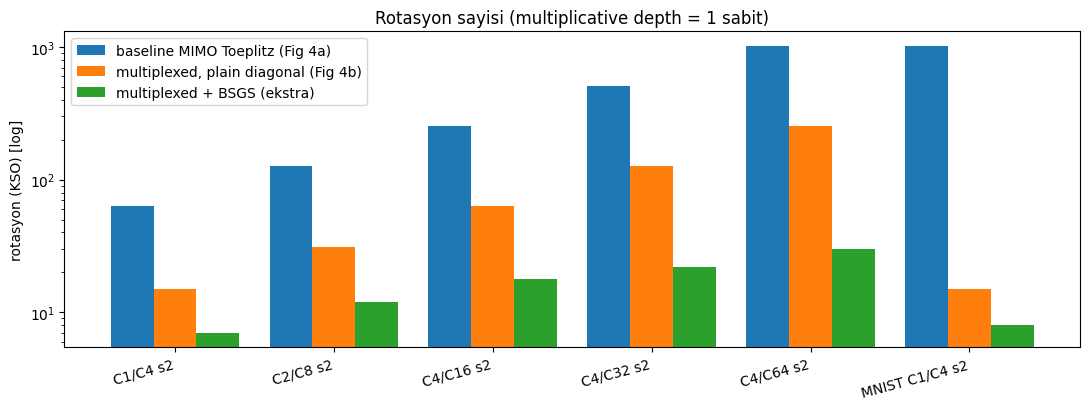

C1/C4 s2         baseline=   63 plain=  15 bsgs=   7
C2/C8 s2         baseline=  127 plain=  31 bsgs=  12
C4/C16 s2        baseline=  255 plain=  63 bsgs=  18
C4/C32 s2        baseline=  511 plain= 127 bsgs=  22
C4/C64 s2        baseline= 1023 plain= 255 bsgs=  30
MNIST C1/C4 s2   baseline= 1023 plain=  15 bsgs=   8


In [10]:
!/content/fhe310/bin/python /content/mimo_mux_fhe.py --mode counts
import json, numpy as np, matplotlib.pyplot as plt
data = json.load(open("/content/rotation_compare.json"))
names=[d["name"] for d in data]; base=[d["baseline"] for d in data]
plain=[d["plain"] for d in data]; bsgs=[d["bsgs"] for d in data]
x=np.arange(len(names)); w=0.27
fig,ax=plt.subplots(figsize=(11,4.2))
ax.bar(x-w, base, w, label="baseline MIMO Toeplitz (Fig 4a)")
ax.bar(x,   plain, w, label="multiplexed, plain diagonal (Fig 4b)")
ax.bar(x+w, bsgs, w, label="multiplexed + BSGS (ekstra)")
ax.set_yscale("log"); ax.set_ylabel("rotasyon (KSO) [log]")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_title("Rotasyon sayisi (multiplicative depth = 1 sabit)"); ax.legend()
plt.tight_layout(); plt.show()
for d in data: print(f"{d['name']:16s} baseline={d['baseline']:>5} plain={d['plain']:>4} bsgs={d['bsgs']:>4}")

## Görseller

MNIST çok-kanallı çıktının plaintext ve homomorfik kanalları (ve farkı).

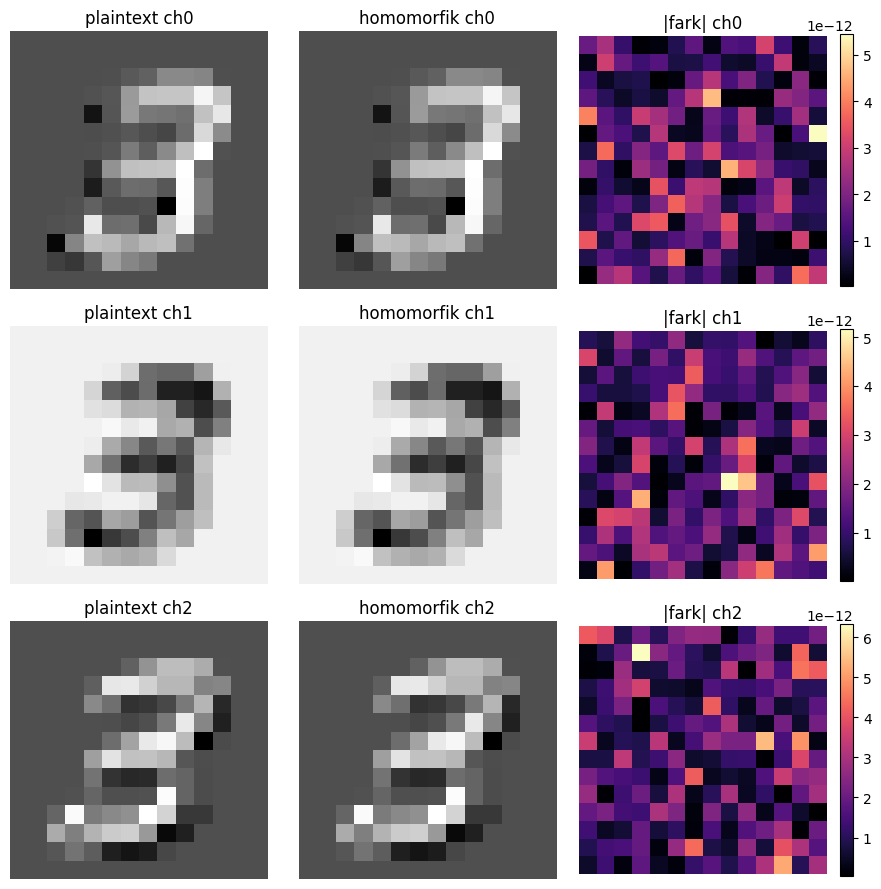

max |fark| = 6.331157820227418e-12


In [11]:
import numpy as np, matplotlib.pyplot as plt
img = np.load("/content/mnist_input.npy"); exp = np.load("/content/mnist_expected.npy")
dec = np.load("/content/mnist_decrypted.npy")
Co = exp.shape[0]; show = min(Co, 3)
fig, ax = plt.subplots(show, 3, figsize=(9, 3.0*show)); ax = np.atleast_2d(ax)
for c in range(show):
    ax[c,0].imshow(exp[c], cmap="gray"); ax[c,0].set_title(f"plaintext ch{c}")
    ax[c,1].imshow(dec[c], cmap="gray"); ax[c,1].set_title(f"homomorfik ch{c}")
    im = ax[c,2].imshow(np.abs(exp[c]-dec[c]), cmap="magma"); ax[c,2].set_title(f"|fark| ch{c}")
    fig.colorbar(im, ax=ax[c,2], fraction=0.046)
    for a in ax[c]: a.axis("off")
plt.tight_layout(); plt.show()
print("max |fark| =", float(np.abs(exp-dec).max()))

## PyTorch çapraz kontrolü



In [12]:
import numpy as np
try:
    import torch, torch.nn.functional as F
    img = np.load("/content/mnist_input.npy"); W = np.load("/content/mnist_weight.npy")
    ref = np.load("/content/mnist_expected.npy"); he = np.load("/content/mnist_decrypted.npy")
    xt = torch.tensor(img[None], dtype=torch.float64); wt = torch.tensor(W, dtype=torch.float64)
    out = F.conv2d(xt, wt, stride=2, padding=1).numpy()[0]
    print("PyTorch == NumPy(Toeplitz):", np.allclose(out, ref, atol=1e-6), f"| max fark {np.abs(out-ref).max():.2e}")
    print("PyTorch == homomorfik     :", np.allclose(out, he,  atol=1e-2), f"| max fark {np.abs(out-he).max():.2e}")
except Exception as e:
    print("torch atlandi:", e)

PyTorch == NumPy(Toeplitz): True | max fark 4.44e-16
PyTorch == homomorfik     : True | max fark 6.33e-12
